# Week 7: Line Plot of IoT Sensor Readings Over Time

This notebook visualizes the Smart Logistics Tracker Japan IoT dataset by plotting selected sensor readings over time. The activity focuses on showing how logistics-related sensor values change across timestamps and how visualization can support monitoring, comparison, and anomaly detection.

## 1. Import Required Libraries

The notebook uses `pandas` for data handling and `matplotlib`/`seaborn` for creating presentation-ready line visualizations.

In [12]:
# Import required libraries
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid", context="notebook")

# Make tabular outputs easier to review
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load the Preprocessed IoT Logistics Data

The dataset is loaded using a repo-friendly relative path. This allows the notebook to run from the main repository folder without hardcoding a local computer path.

In [13]:
# Define possible CSV locations for flexible notebook execution
candidate_paths = [
    Path("IOT Data Simulation") / "smart_logistic_tracker_japan.csv",
    Path.cwd() / "IOT Data Simulation" / "smart_logistic_tracker_japan.csv",
    Path("smart_logistic_tracker_japan.csv")
]

# Select the first existing path
file_path = next((path for path in candidate_paths if path.exists()), None)

# Stop execution with a clear message if the CSV file is not found
if file_path is None:
    raise FileNotFoundError(
        "CSV file not found. Expected location: "
        "adet/IOT Data Simulation/smart_logistic_tracker_japan.csv"
    )

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first few rows to confirm successful loading
df.head()

,timestamp,carrier,tracking_number,package_id,origin,current_location,delivery_location,prefecture,latitude,longitude,latest_status,logistics_delay_reason,logistics_delay,order_date,expected_delivery_date,waiting_time_minutes,perishable,temperature,humidity,rfid_tag,rfid_verified,tamper_alert,traffic_status,inventory_level,asset_utilization
0,2026-05-04 13:50:26.857905,Yamato Transport,942646961460,PKG7545,Tokyo,Naha Central Post Office,Tokyo,Kanagawa,35.993159,139.038781,Out for Delivery,NaN,0,2026-04-29 23:26:26.858009,2026-05-05 23:26:26.858015,45,No,10.7,40,RFID736892,False,No,Heavy,99,84.59
1,2026-05-03 23:36:26.858095,Japan Post,74355111775,PKG2659,Tokyo,Nagoya Central Post Office,Kyoto,Kanagawa,35.691292,139.130870,Arrival,NaN,0,2026-04-28 23:26:26.858141,2026-05-07 23:26:26.858146,54,Yes,6.2,82,RFID156229,False,Yes,Detour,363,53.39
2,2026-05-04 08:32:26.858217,Japan Post,217497030475,PKG7965,Osaka,Nagoya Central Post Office,Osaka,Aichi,35.591109,139.784940,Storage,NaN,1,2026-05-03 23:26:26.858267,2026-05-08 23:26:26.858271,144,Yes,-3.1,86,RFID890703,True,Yes,Heavy,25,95.75
3,2026-05-04 02:35:26.858332,Japan Post,249781996688,PKG5296,Fukuoka,Sapporo Central Post Office,Sapporo,Osaka,35.570440,139.689163,Delivered to the delivery address,NaN,0,2026-05-03 23:26:26.858370,2026-05-05 23:26:26.858374,173,Yes,6.3,87,RFID603182,True,Yes,Detour,145,63.84
4,2026-05-04 08:28:26.858444,Japan Post,718415724062,PKG9987,Fukuoka,Yokohama Sales Office,Sapporo,Hokkaido,35.679375,139.408071,Bring it back due to your absence,Address Unknown,1,2026-05-03 23:26:26.858492,2026-05-07 23:26:26.858501,82,No,0.7,60,RFID921432,False,Yes,Detour,34,56.28


## 3. Check the Dataset Structure

The dataset shape, column names, and data types are reviewed before visualization to confirm that the required fields are available.

In [14]:
# Display dataset size and column information
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (100, 25)

Column names:
['timestamp', 'carrier', 'tracking_number', 'package_id', 'origin', 'current_location', 'delivery_location', 'prefecture', 'latitude', 'longitude', 'latest_status', 'logistics_delay_reason', 'logistics_delay', 'order_date', 'expected_delivery_date', 'waiting_time_minutes', 'perishable', 'temperature', 'humidity', 'rfid_tag', 'rfid_verified', 'tamper_alert', 'traffic_status', 'inventory_level', 'asset_utilization']

Data types:
timestamp                  object
carrier                    object
tracking_number             int64
package_id                 object
origin                     object
current_location           object
delivery_location          object
prefecture                 object
latitude                  float64
longitude                 float64
latest_status              object
logistics_delay_reason     object
logistics_delay             int64
order_date                 object
expected_delivery_date     object
waiting_time_minute

## 4. Convert Timestamp to Datetime Format

The `timestamp` column is converted to a datetime format to support proper time-series plotting. Records are also sorted chronologically before visualization.

In [15]:
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort records by timestamp for correct line plot order
df = df.sort_values("timestamp").reset_index(drop=True)

# Preview selected columns after timestamp conversion
df[["timestamp", "package_id", "temperature", "humidity", "inventory_level", "asset_utilization"]].head()

,timestamp,package_id,temperature,humidity,inventory_level,asset_utilization
0,2026-05-03 23:27:26.867138,PKG8417,7.6,74,26,79.21
1,2026-05-03 23:33:26.865949,PKG3700,15.6,55,117,85.29
2,2026-05-03 23:36:26.858095,PKG2659,6.2,82,363,53.39
3,2026-05-03 23:44:26.861259,PKG3751,16.3,76,331,73.53
4,2026-05-03 23:49:26.862100,PKG9613,2.2,72,133,73.33


## 5. Prepare Sensor Readings for Visualization

The following IoT-related numeric readings are selected for the line plots:

- Temperature
- Humidity
- Inventory Level
- Asset Utilization

Hourly averaging is applied to reduce visual clutter caused by multiple package records occurring within similar time periods. This keeps the graph readable while preserving the overall movement of the sensor readings.

In [16]:
# Select IoT sensor-related numeric readings
sensor_columns = [
    "temperature",
    "humidity",
    "inventory_level",
    "asset_utilization"
]

# Define display labels for chart legends and titles
sensor_labels = {
    "temperature": "Temperature",
    "humidity": "Humidity",
    "inventory_level": "Inventory Level",
    "asset_utilization": "Asset Utilization"
}

# Define a consistent color mapping across all visualizations
sensor_colors = {
    "Temperature": "#4C72B0",        # blue
    "Humidity": "#DD8452",           # orange
    "Inventory Level": "#55A868",    # green
    "Asset Utilization": "#C44E52"   # red
}

# Aggregate readings by hour to improve readability of the time-series plots
hourly_df = (
    df.set_index("timestamp")[sensor_columns]
      .resample("1H")
      .mean()
      .dropna(how="all")
      .reset_index()
)

# Convert the hourly dataset into long format for multi-sensor line plotting
hourly_long = hourly_df.melt(
    id_vars="timestamp",
    value_vars=sensor_columns,
    var_name="sensor_type",
    value_name="sensor_value"
)

# Apply readable sensor names
hourly_long["sensor_type"] = hourly_long["sensor_type"].replace(sensor_labels)

# Display the prepared long-format dataset
hourly_long.head()

/var/folders/fq/wg6mt70d12361qx6fnd63pjc0000gn/T/ipykernel_62488/2336056442.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


,timestamp,sensor_type,sensor_value
0,2026-05-03 23:00:00,Temperature,8.528571
1,2026-05-04 00:00:00,Temperature,7.200000
2,2026-05-04 01:00:00,Temperature,5.240000
3,2026-05-04 02:00:00,Temperature,5.080000
4,2026-05-04 04:00:00,Temperature,8.780000


## 6. Non-Normalized Line Plot of IoT Sensor Readings Over Time

This chart shows the actual sensor values using their original scales. It is useful for reviewing the real recorded values, although larger-scale variables such as inventory level may visually dominate smaller-scale readings.

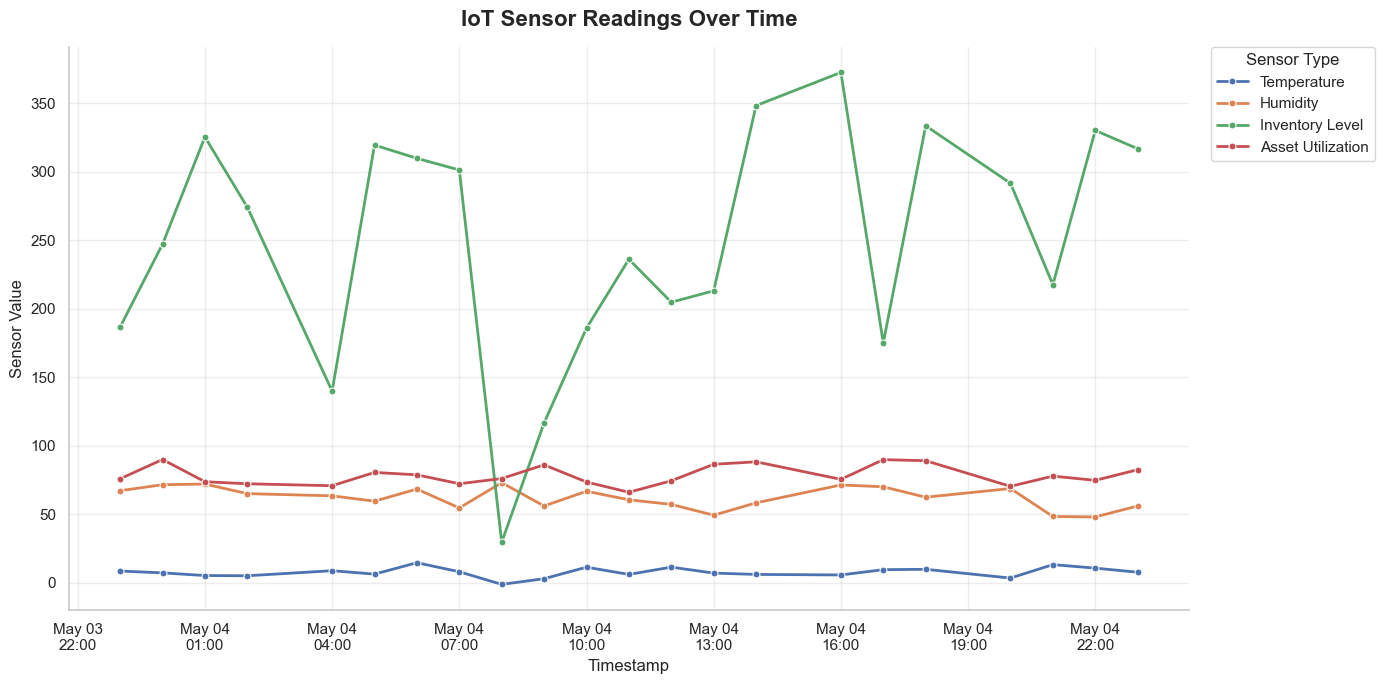

In [17]:
# Set the order of sensor categories in the legend
sensor_order = list(sensor_colors.keys())

# Create the non-normalized multi-sensor line plot
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=hourly_long,
    x="timestamp",
    y="sensor_value",
    hue="sensor_type",
    hue_order=sensor_order,
    palette=sensor_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Sensor Readings Over Time", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Sensor Value", fontsize=12)

# Format x-axis labels using 3-hour intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Sensor Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 7. Normalized Line Plot for Easier Comparison

The normalized chart rescales each selected sensor reading between 0 and 1. This makes it easier to compare movement patterns across sensor types even when their original measurement scales are different.

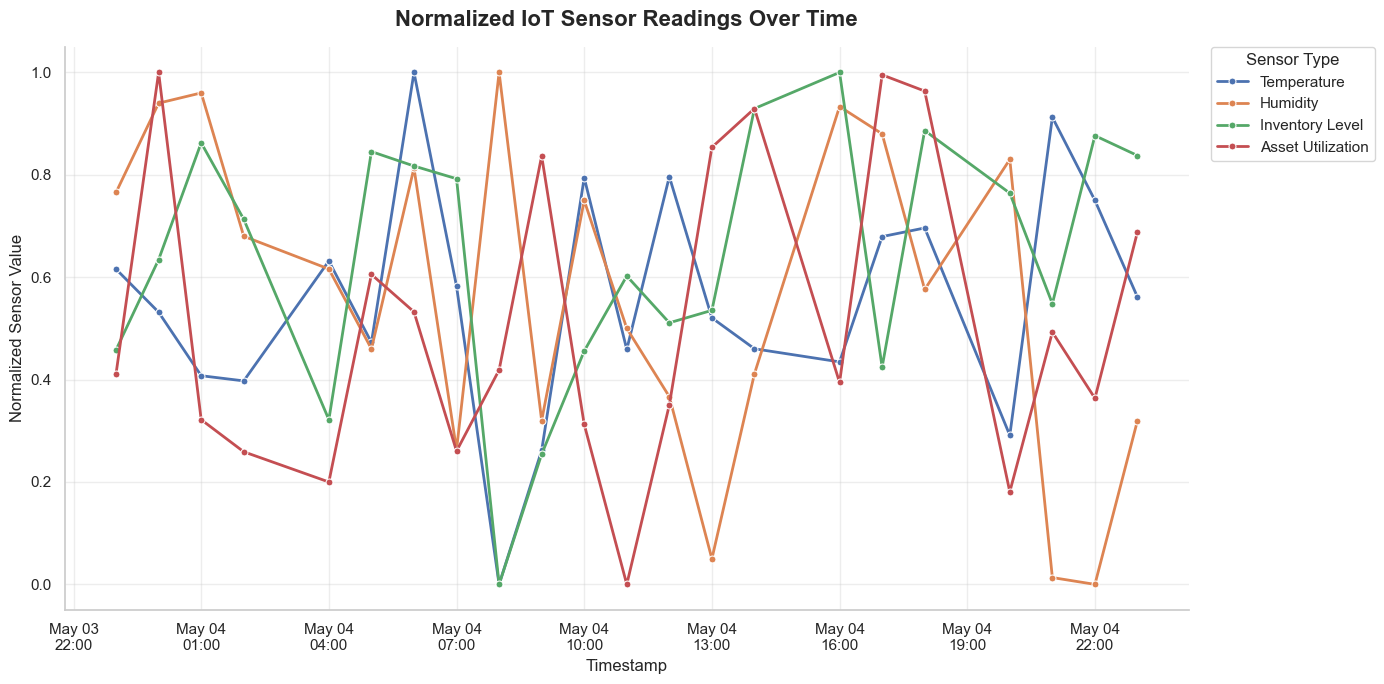

In [18]:
# Create a normalized copy of the hourly sensor readings
normalized_df = hourly_df.copy()

for col in sensor_columns:
    min_value = normalized_df[col].min()
    max_value = normalized_df[col].max()
    
    # Avoid division by zero if a column contains only one unique value
    if max_value == min_value:
        normalized_df[col] = 0
    else:
        normalized_df[col] = (normalized_df[col] - min_value) / (max_value - min_value)

# Convert normalized data into long format
normalized_long = normalized_df.melt(
    id_vars="timestamp",
    value_vars=sensor_columns,
    var_name="sensor_type",
    value_name="normalized_value"
)

# Apply readable sensor names
normalized_long["sensor_type"] = normalized_long["sensor_type"].replace(sensor_labels)

# Create the normalized multi-sensor line plot
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=normalized_long,
    x="timestamp",
    y="normalized_value",
    hue="sensor_type",
    hue_order=sensor_order,
    palette=sensor_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("Normalized IoT Sensor Readings Over Time", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Normalized Sensor Value", fontsize=12)

# Format x-axis labels using 3-hour intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Sensor Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 8. Separate Sensor Trend Visualizations

Separate line plots provide a clearer view of each sensor reading without scale interference from other variables. The same color mapping from the multi-sensor charts is retained for consistency.

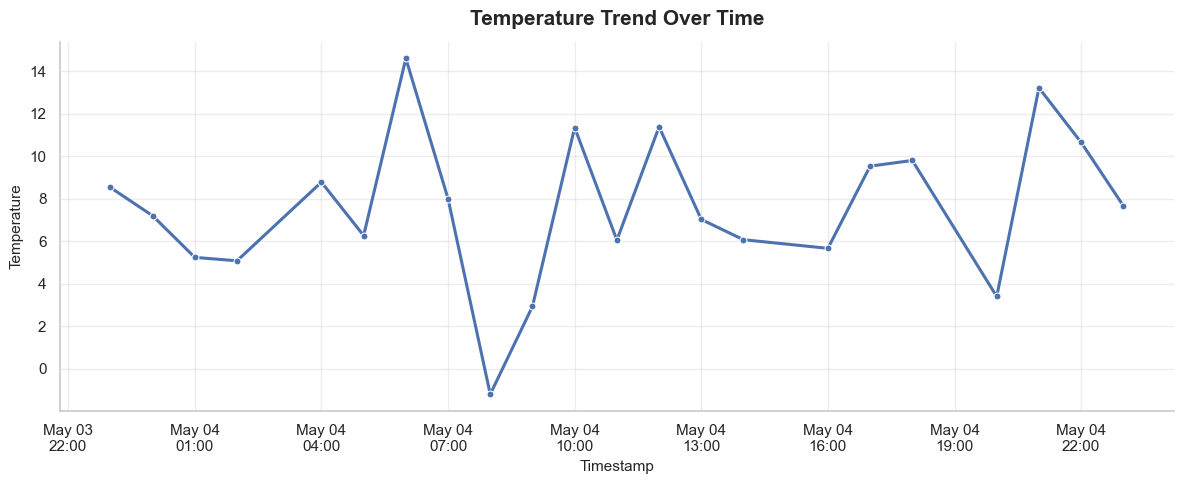

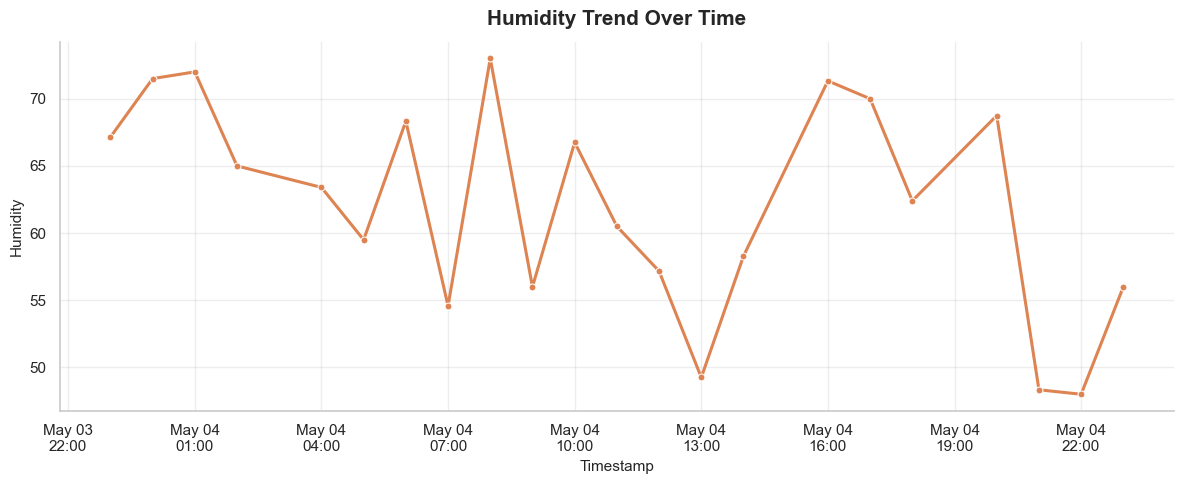

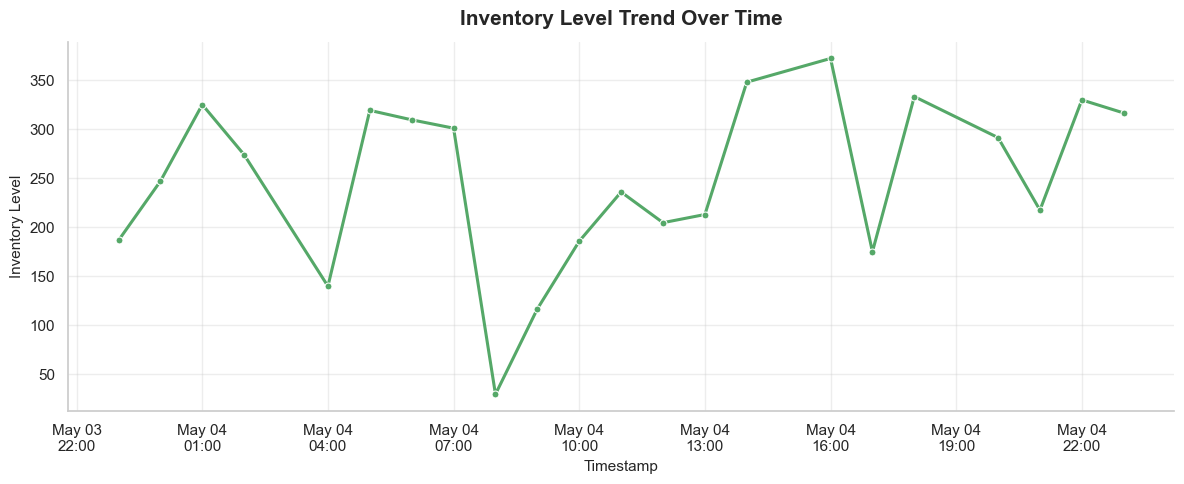

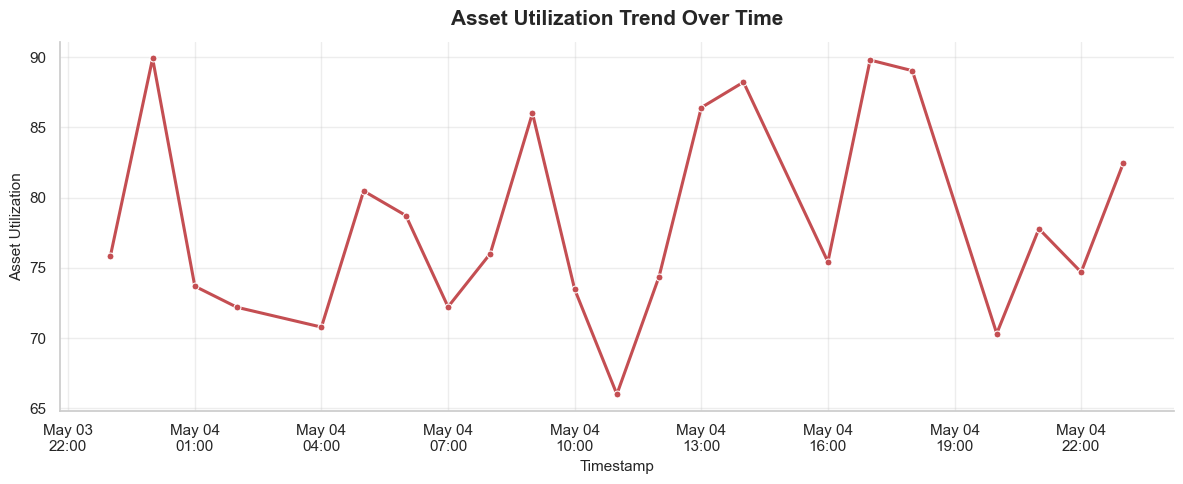

In [19]:
# Create one separate trend visualization per sensor reading
for col in sensor_columns:
    label = sensor_labels[col]
    color = sensor_colors[label]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    sns.lineplot(
        data=hourly_df,
        x="timestamp",
        y=col,
        color=color,
        marker="o",
        markersize=5,
        linewidth=2.2,
        ax=ax
    )
    
    # Add chart title and axis labels
    ax.set_title(f"{label} Trend Over Time", fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel("Timestamp", fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    
    # Format x-axis labels using 3-hour intervals
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    
    # Improve plot readability
    ax.grid(True, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 9. Brief Observation

The non-normalized line plot shows the actual sensor readings across time, while the normalized version makes the movement patterns easier to compare across different measurement scales. The separate sensor trend plots provide a clearer view of each reading individually, which is useful when checking fluctuations, spikes, drops, and possible anomalies in logistics monitoring data.

## Conclusion

The line visualizations show how selected IoT sensor readings from the Smart Logistics Tracker Japan dataset change over time. These graphs help make logistics data more interpretable by supporting the review of shipment conditions, inventory movement, asset utilization, and possible irregular patterns in sensor activity.